# TESTS

In [1]:
import sys, os
from astropy.table import Table
import astropy.units as u
sys.path.append('../')
import host_copilot

ra, dec = 337.06898566934177, 50.76435780243545
r = 180 #arcsec

In [2]:
hostpipe = host_copilot.HostPipeline(ra, dec, r, save_path='/Volumes/T7/Shared_Files/EP/EP-TA-data/260725/ep11916655582wxtCMOS16l23v2_20260725_194118/host')
aladin, result = hostpipe.run()
aladin

[QUICK MODE]
Searching for galaxies...
Querying REGALADE catalog...
--------------------------------------------------

Found 3 galaxies in the REGLADE catalog within the specified redshift cut (z<0.1) and radius r=180 arcsec.
--------------------------------------------------
Galaxy: WISEA J222804.94+504346., z=0.054, sep=166.84
Galaxy: LEDA   97246, z=0.015, sep=43.63
Galaxy: 2MASX J22281677+5047231, z=0.026, sep=91.51
HostPipeline run completed.


In [3]:
from host_copilot.image import Imager

imager = Imager(ra=ra,dec=dec,r_arcsec=r,save_path='/Volumes/T7/Shared_Files/EP/EP-TA-data/260725/ep11916655582wxtCMOS16l23v2_20260725_194118/host')
imager.PS_cutout()

Saved PS1 cutout to /Volumes/T7/Shared_Files/EP/EP-TA-data/260725/ep11916655582wxtCMOS16l23v2_20260725_194118/host/ps1_r_ref.fits


'/Volumes/T7/Shared_Files/EP/EP-TA-data/260725/ep11916655582wxtCMOS16l23v2_20260725_194118/host/ps1_r_ref.fits'

## Statistics of EP Transients

In [5]:
transient_tbl = Table.read('/Volumes/T7/Shared_Files/EP/Projects/Host_copilot/examples/EP_data/summary.csv')
transient_tbl_host = transient_tbl[transient_tbl['candidate_count']>0]

n_total = len(transient_tbl)
n_host_cand = len(transient_tbl_host)

print(f"{n_host_cand}/{n_total} have host candidate with z<0.1")

17/71 have host candidate with z<0.1


Text(0.5, 0, 'z')

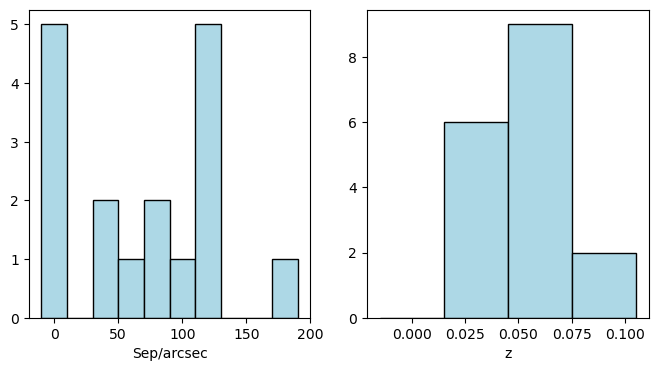

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1,2,figsize=(8,4),dpi=100)

ax[0].hist(transient_tbl_host['nearest_sep_arcsec'], bins=np.linspace(0,200,11), align='left', color='lightblue', edgecolor='black')
ax[1].hist(transient_tbl_host['nearest_z'], bins=np.linspace(0,0.12,5), align='left', color='lightblue', edgecolor='black')

ax[0].set_xlabel('Sep/arcsec')
ax[1].set_xlabel('z')